In [1]:
import os
os.chdir("./..")

from PVDatasetWithHistory import PVDatasetWithHistory

ds = PVDatasetWithHistory(r"C:\Users\peter\Repos\ENFIELD-data\processed_unpack\nwp_0h", previous_days=5, split="train")

x, y, meta = ds[0]

In [2]:
import numpy as np

aggregate = {}

for key in x.keys():
    aggregate[key] = np.array([])

In [133]:
from tqdm import tqdm

indices = np.arange(len(ds))
np.random.shuffle(indices)

for i in tqdm(range(100000)):
    x, y, meta = ds[indices[i]]
    for key in x.keys():
        aggregate[key] = np.concatenate((aggregate[key], x[key].numpy()))

 64%|██████▍   | 64348/100000 [1:37:34<54:03, 10.99it/s]  


KeyboardInterrupt: 

In [134]:
aggregate.keys()

dict_keys(['dhi', 'ghi', 'dni', 'wind_speed', 'temp_air', 'unix_timestamps', 'solar_zenith', 'solar_azimuth'])

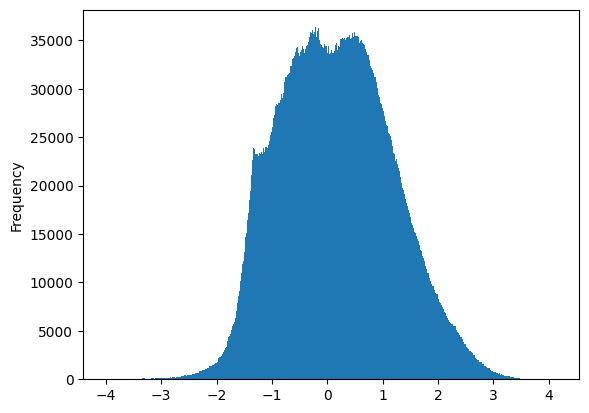

In [153]:
import matplotlib.pyplot as plt

plt.hist((aggregate['temp_air'] - 11) / 8, bins=500)
plt.ylabel('Frequency')
plt.show()

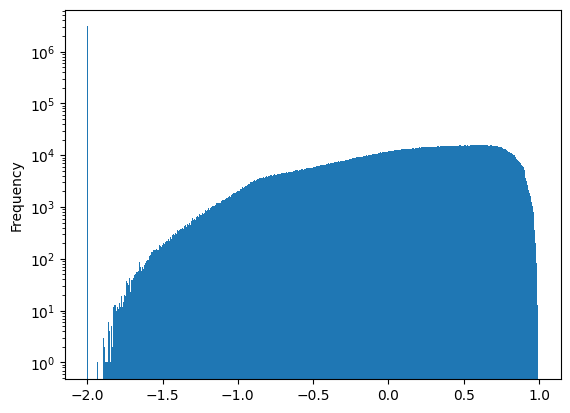

In [152]:
plt.hist(np.log10(aggregate['ghi'] + 1) - 2, bins=500)
plt.yscale('log')
plt.ylabel('Frequency')
plt.show()

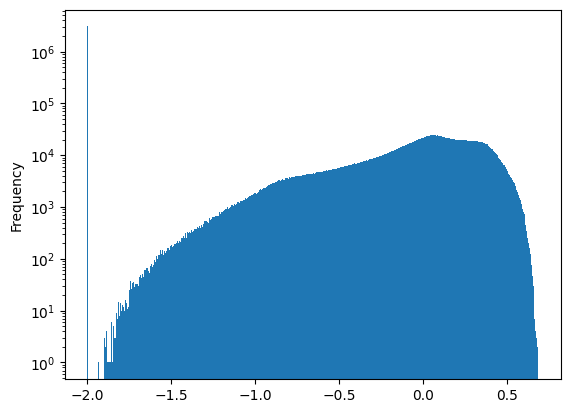

In [151]:
plt.hist(np.log10(aggregate['dni'] + 1) - 2, bins=500)
plt.yscale('log')
plt.ylabel('Frequency')
plt.show()

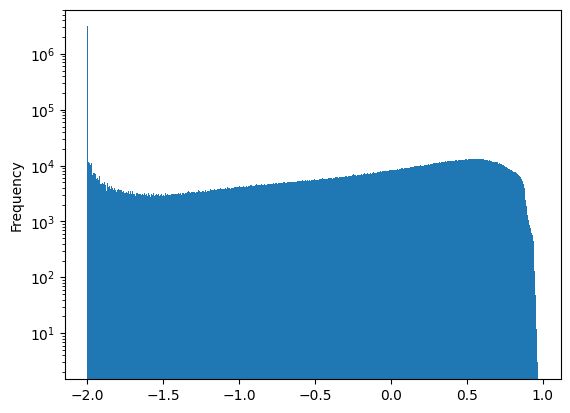

In [150]:
plt.hist(np.log10(aggregate['dhi'] + 1) - 2, bins=500)
plt.yscale('log')
plt.ylabel('Frequency')
plt.show()

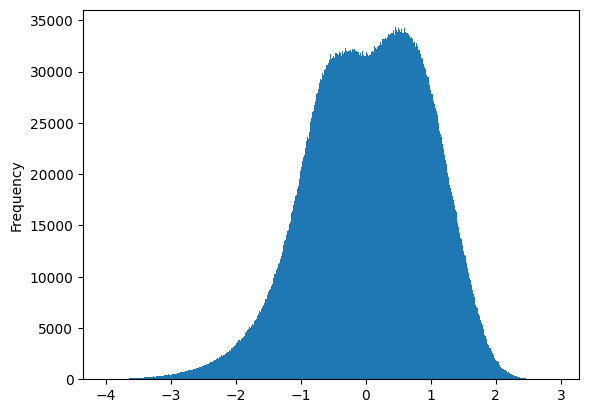

In [149]:
plt.hist((np.log10(aggregate['wind_speed'] + 0.1) - 1/3) * 3, bins=500)
plt.ylabel('Frequency')
plt.show()

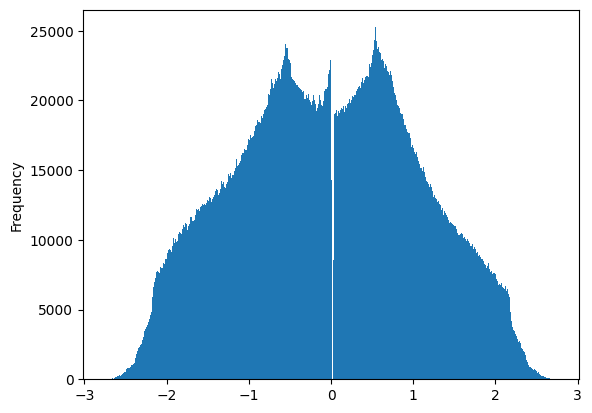

In [162]:
plt.hist((aggregate['solar_zenith'] - np.pi / 2) * 2, bins=500)
plt.ylabel('Frequency')
plt.show()

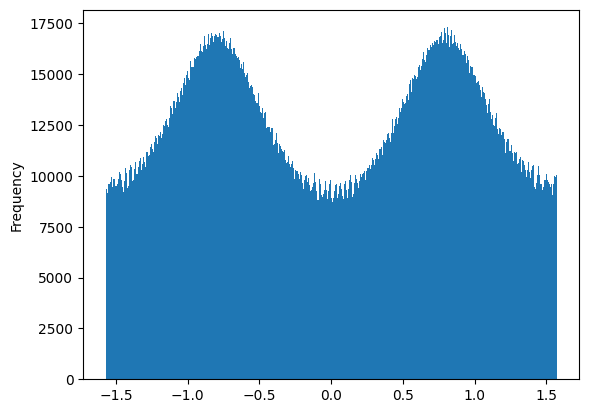

In [179]:
plt.hist((aggregate['solar_azimuth'] - np.pi) / 2, bins=500)
plt.ylabel('Frequency')
plt.show()

In [168]:
(aggregate['solar_azimuth'] - np.pi).std()

np.float64(1.7847820733765545)

In [ ]:
def normalize_inputs(x):
    for key in x.keys():
        if 'temp_air' in key:
            x[key] = (x[key] - 11) / 8
        elif 'ghi' in key or 'dni' in key or 'dhi' in key:
            x[key] = np.log10(x[key] + 1) - 2
        elif 'wind_speed' in key:
            x[key] = (np.log10(x[key] + 0.1) - 1/3) * 3
        elif 'solar_zenith' in key:
            x[key] = (x[key] - np.pi / 2) * 2
        elif 'solar_azimuth' in key:
            x[key] = (x[key] - np.pi) / 2

In [2]:
from utils.normalize import normalize_inputs

x_norm = normalize_inputs(x)

In [8]:
import torch

x_tensor = torch.tensor(list(x_norm.values()))

ValueError: only one element tensors can be converted to Python scalars

In [ ]:
batch_size = 16
seq_length = 96